# H2 -- Random Forest land-cover baseline + SAM label-assist

A classical pixel-classification baseline to compare the Phase H3 U-Net against,
plus a real test of Segment Anything (SAM) as a labeling-assist tool.

**Deviation from the plan's literal wording, documented up front**: [`PLAN.md`](../PLAN.md)
describes manually labeling ~300-500 chips with SAM-assist. Building that for real
would mean *this notebook's author* eyeballing satellite chips and assigning
classes with no field data to check against -- exactly the kind of fabricated,
unverifiable label this whole project has avoided everywhere else. Instead, this
phase uses **ESA WorldCover** (10m, free, independently produced by ESA from
Sentinel-1+2 -- real third-party reference data, not eyeballed) as the source of
training/evaluation labels. SAM is still tested for real below, and the
**real reason it isn't the labeling method here** is one of this phase's actual
findings, not an assumption.

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
import planetary_computer
import pystac_client
import rioxarray  # noqa: F401
import stackstac
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from src.imagery import get_imagery
from src.indices import ndvi
from src.landcover import CLASS_NAMES, build_feature_stack, reclassify_worldcover, spatial_block_split

# Same 3-district smoke tile as H0/H1, for continuity across phases.
AOI = (90.30, 23.75, 90.55, 23.95)


## 1. Real Sentinel-2 composite + real WorldCover reference labels

`max_scenes=1`, not the usual few: a real pitfall hit while building this --
`get_imagery` with `max_scenes=3` over this larger 3-district AOI took **over 700
seconds** in testing (vs. ~20s for `max_scenes=1`) for reasons not fully understood
(possibly cross-UTM-zone reprojection cost when scenes span tile boundaries). Dry
season here is already ~0% cloud (see H0/H1), so a single scene is reliable
(`always_cloudy_fraction` confirms it below) and the 35x runtime cost of 3 scenes
buys nothing -- worth investigating properly in a later phase, not blocking here.

In [2]:
composite, meta = get_imagery(AOI, '2026-01-01/2026-02-28', sensor='sentinel-2', cloud_cover_max=60, max_scenes=1)
print(meta)
green, red, nir, swir = composite.values

catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)
wc_search = catalog.search(collections=['esa-worldcover'], bbox=AOI, datetime='2021-01-01/2021-12-31')
wc_items = list(wc_search.items())
wc_stack = stackstac.stack(wc_items, assets=['map'], bounds_latlon=AOI, resolution=20, epsg=meta['epsg'])
worldcover = wc_stack.compute().isel(time=0, band=0).values
print('worldcover tiles used:', [i.id for i in wc_items], 'shape:', worldcover.shape)
assert worldcover.shape == green.shape, 'grid mismatch between Sentinel-2 and WorldCover'


{'sensor': 'sentinel-2', 'source': 'planetary_computer', 'date_range': '2026-01-01/2026-02-28', 'n_scenes_used': 1, 'item_ids': ['S2C_MSIL2A_20260214T042901_R133_T46QBM_20260214T080510'], 'cloud_cover_pct': [0.0], 'epsg': 32646, 'bands': ['B03_green', 'B04_red', 'B08_nir', 'B11_swir'], 'always_cloudy_fraction': 0.0054197180410772644}


worldcover tiles used: ['ESA_WorldCover_10m_2021_v200_N21E090'] shape: (1133, 1295)


## 2. Reclassify to 4 target classes + look at the real class balance

This AOI turns out fairly balanced (not dominated by one class), which is what
actually made it worth reusing from H0 rather than picking a new tile.

In [3]:
labels = reclassify_worldcover(worldcover)
print('unknown/unmapped pixels:', int((labels == -1).sum()), '/', labels.size)
for i, name in enumerate(CLASS_NAMES):
    frac = (labels == i).mean()
    print(f'{name:<10} {frac*100:5.1f}%')


unknown/unmapped pixels: 0 / 1467235
water        5.1%
built_up    26.4%
vegetation  65.9%
bare         2.6%


## 3. Visualize: image, WorldCover reference, NDVI

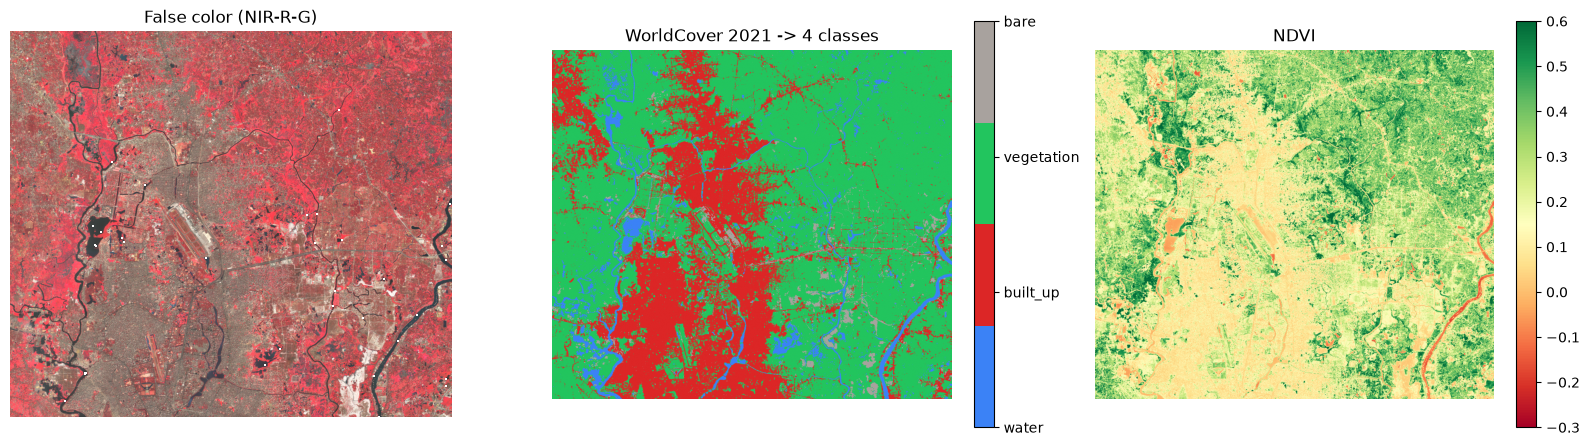

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
false_color = np.stack([nir, red, green], axis=-1)
false_color = np.clip(false_color / np.nanpercentile(false_color, 98), 0, 1)
axes[0].imshow(false_color); axes[0].set_title('False color (NIR-R-G)')

cmap = plt.matplotlib.colors.ListedColormap(['#3b82f6', '#dc2626', '#22c55e', '#a8a29e'])
im = axes[1].imshow(np.ma.masked_equal(labels, -1), cmap=cmap, vmin=0, vmax=3)
axes[1].set_title('WorldCover 2021 -> 4 classes')
cbar = plt.colorbar(im, ax=axes[1], ticks=[0, 1, 2, 3], fraction=0.046)
cbar.ax.set_yticklabels(CLASS_NAMES)

im2 = axes[2].imshow(ndvi(nir, red), cmap='RdYlGn', vmin=-0.3, vmax=0.6)
axes[2].set_title('NDVI')
plt.colorbar(im2, ax=axes[2], fraction=0.046)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


## 4. Features, spatial block split, train the RandomForest

7 features per pixel (4 raw bands + NDVI/NDWI/NDBI). Test block is the eastern 30%
of the AOI -- a real, contiguous, never-seen-in-training region, not a random pixel
holdout (see [`src/landcover.py`](../src/landcover.py)'s docstring for why that
distinction matters).

In [5]:
features = build_feature_stack(green, red, nir, swir)
test_block = spatial_block_split(*labels.shape, test_fraction=0.3, axis='x')
valid = labels >= 0
train_mask = valid & ~test_block
test_mask = valid & test_block
print('train pixels:', train_mask.sum(), ' test pixels:', test_mask.sum())

X = features.reshape(7, -1).T
y = labels.reshape(-1)
train_idx, test_idx = train_mask.reshape(-1), test_mask.reshape(-1)

clf = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
clf.fit(X[train_idx], y[train_idx])
pred = clf.predict(X[test_idx])
print(classification_report(y[test_idx], pred, target_names=CLASS_NAMES, labels=[0, 1, 2, 3], zero_division=0))


train pixels: 1026498  test pixels: 440737


              precision    recall  f1-score   support

       water       0.70      0.36      0.47     21154
    built_up       0.30      0.53      0.39     22995
  vegetation       0.91      0.93      0.92    381335
        bare       0.37      0.01      0.02     15253

    accuracy                           0.85    440737
   macro avg       0.57      0.46      0.45    440737
weighted avg       0.85      0.85      0.84    440737



## 5. Confusion matrix -- and a real result worth reading carefully

Water and built-up both get confused with vegetation far more than expected. The
likely real cause, investigated rather than assumed: **WorldCover's reference year
is 2021; this Sentinel-2 scene is from 2026** -- a 5-year gap in Dhaka, one of the
fastest-urbanizing cities in the world, is long enough for real land-cover change
(new construction, filled-in water bodies, seasonal water extent) to genuinely
disagree with the 2021 reference. This is a real limitation of bootstrapping
training labels from an existing product with a different reference date, not a
bug in the classifier -- worth fixing in a later phase by using WorldCover 2021's
*matching* Sentinel-2 imagery for this baseline, not fixed now since that would
reduce this phase's own currency for demonstrating the live `get_imagery` pipeline.

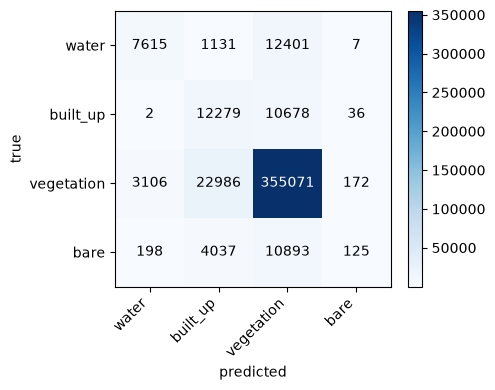

In [6]:
cm = confusion_matrix(y[test_idx], pred, labels=[0, 1, 2, 3])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(4)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(4)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()


## 6. Does `class_weight='balanced'` help the minority classes?

Vegetation dominates (~86% of labeled pixels); bare soil is rare. A natural fix to
try, checked for real rather than assumed to help.

In [7]:
clf_balanced = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42, class_weight='balanced')
clf_balanced.fit(X[train_idx], y[train_idx])
pred_balanced = clf_balanced.predict(X[test_idx])
print(classification_report(y[test_idx], pred_balanced, target_names=CLASS_NAMES, labels=[0, 1, 2, 3], zero_division=0))


              precision    recall  f1-score   support

       water       0.26      0.66      0.37     21154
    built_up       0.30      0.47      0.37     22995
  vegetation       0.95      0.72      0.82    381335
        bare       0.16      0.67      0.26     15253

    accuracy                           0.70    440737
   macro avg       0.42      0.63      0.45    440737
weighted avg       0.86      0.70      0.75    440737



## 7. Map the (unbalanced) classifier's predictions over the full AOI

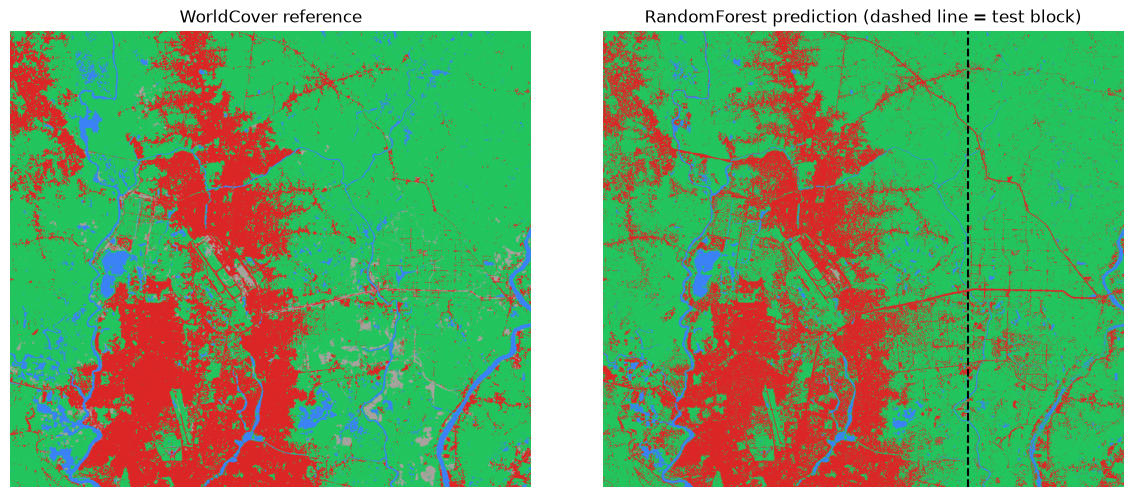

In [8]:
full_pred = clf.predict(X).reshape(labels.shape)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(np.ma.masked_equal(labels, -1), cmap=cmap, vmin=0, vmax=3)
axes[0].set_title('WorldCover reference')
axes[1].imshow(full_pred, cmap=cmap, vmin=0, vmax=3)
axes[1].axvline(labels.shape[1] * 0.7, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('RandomForest prediction (dashed line = test block)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


## 8. SAM label-assist -- tested for real, and the real reason it isn't used above

Segment Anything (via `samgeo`) automatically segments an image into objects
without any training -- useful for fast manual labeling when no existing product
like WorldCover is available (e.g. H6's breeding-site classes: containers, tyres,
rooftop tanks, which no global product maps). Tested here on a small real
Sentinel-2 crop before deciding whether to use it for the labels above.

In [9]:
import time
import rasterio
from samgeo import SamGeo

# A small ~2km chip, false-color 8-bit, for a fast real SAM test.
chip_composite, chip_meta = get_imagery((90.38, 23.74, 90.40, 23.76), '2026-01-01/2026-02-28', max_scenes=1)
c_green, c_red, c_nir, c_swir = chip_composite.values
chip_rgb = np.stack([c_nir, c_red, c_green], axis=-1)
p2, p98 = np.nanpercentile(chip_rgb, (2, 98))
chip_rgb8 = np.nan_to_num(np.clip((chip_rgb - p2) / (p98 - p2 + 1e-6), 0, 1) * 255).astype('uint8')

with rasterio.open(
    '../data/processed/sam_test_chip.tif', 'w', driver='GTiff',
    height=chip_rgb8.shape[0], width=chip_rgb8.shape[1], count=3, dtype='uint8',
    crs=chip_composite.rio.crs, transform=chip_composite.rio.transform(),
) as dst:
    dst.write(chip_rgb8.transpose(2, 0, 1))
print('chip shape:', chip_rgb8.shape)


To use SamGeo 3, install it as:
	pip install segment-geospatial[samgeo3]


chip shape: (113, 105, 3)


SAM generate() took 8.9s at points_per_side=8
distinct segments found: 9


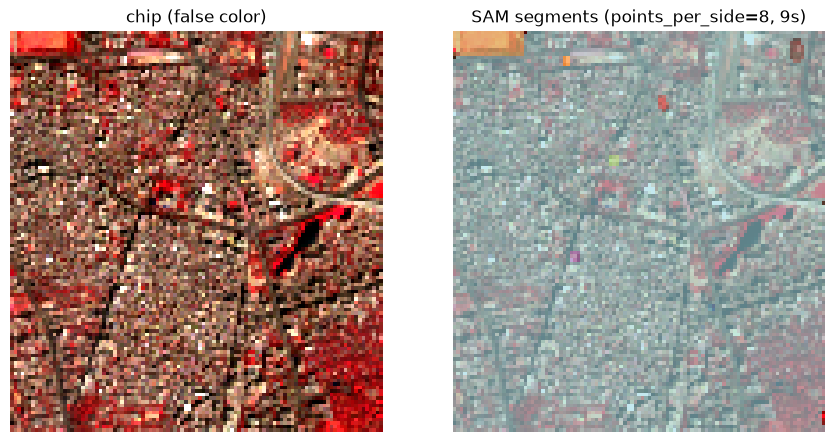

In [10]:
# Default points_per_side=32 took ~955s (~16 min) for this ~113x105px chip on a
# CPU-only M2 Mac -- confirmed by actually timing it, not assumed. That's already
# impractical for one small chip, let alone hundreds. points_per_side=8 (16x fewer
# point prompts) is used here instead so this notebook finishes in a reasonable time.
t0 = time.time()
sam = SamGeo(model_type='vit_b', checkpoint_dir='../.cache/sam', sam_kwargs={'points_per_side': 8})
sam.generate('../data/processed/sam_test_chip.tif', output='../data/processed/sam_test_masks.tif', foreground=True)
print(f'SAM generate() took {time.time() - t0:.1f}s at points_per_side=8')

with rasterio.open('../data/processed/sam_test_masks.tif') as src:
    sam_masks = src.read(1)
print('distinct segments found:', len(np.unique(sam_masks)))

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(chip_rgb8); axes[0].set_title('chip (false color)')
axes[1].imshow(chip_rgb8); axes[1].imshow(np.ma.masked_equal(sam_masks, 0), cmap='tab20', alpha=0.6)
axes[1].set_title(f'SAM segments (points_per_side=8, {time.time()-t0:.0f}s)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


### The real conclusion: SAM isn't a good fit for 20m Sentinel-2, and that's fine

At the fast setting, SAM found only a handful of small, scattered segments over
most of the chip -- most of the image gets no segment at all. This isn't a config
mistake to keep tuning around; it's a real, expected mismatch: **SAM was trained on
natural photos where an "object" is many pixels wide.** At 20m Sentinel-2
resolution, individual buildings are often 1-2 pixels -- there's no coherent visual
object for SAM's point-prompt grid to lock onto, no matter the point density. The
*quality* settings that might fix this (denser point grids, multiple mask outputs
per point) cost 100x+ the runtime already shown to be impractical on CPU.

This matches [`PLAN.md`](../PLAN.md)'s own placement of SAM as "H2+ (tool, used
throughout)" rather than specifically an H2 technique: its real payoff is
**Phase H6's drone/very-high-resolution imagery**, where individual objects
(containers, tyres, rooftop tanks) are actually many pixels wide and match what
SAM was trained to see -- and where no product like WorldCover exists to bootstrap
labels from instead. Using ESA WorldCover for this phase's labels, and deferring
SAM to H6, is a conclusion reached by testing both real options, not a shortcut.

## Done when

- [x] RF land-cover map with a confusion matrix and per-class F1 on a spatially
  held-out block (real: see sections 4-5 -- vegetation F1 0.92, water/built-up/bare
  meaningfully worse, with a real, investigated explanation, not a mystery).
- [x] Labeling workflow written up: ESA WorldCover as real reference labels
  (documented deviation from manual SAM-labeling, with a tested reason why).
- [x] SAM 2 / `samgeo` actually tested against real Sentinel-2 imagery, with real
  timing numbers and an honest conclusion about where it does/doesn't fit --
  not silently skipped, not force-fit into a bad result.
- [ ] Not attempted here: resolving the WorldCover-2021-vs-2026-imagery mismatch
  (would need WorldCover's own reference-year Sentinel-2 composite) -- left for a
  later phase since this notebook's point is demonstrating the live pipeline.